## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings

warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

## Load data

In [2]:
df = pd.read_csv("M3_152_0.csv", header=None, names=["Year number", "Value"])
df["Year number"] += 1

In [3]:
df.head()

,Year number,Value
0,1,5717.0
1,2,6374.0
2,3,5837.5
3,4,7318.4
4,5,4613.0


In [4]:
print(f"Всего в dataframe {len(df)} наблюдений.")

Всего в dataframe 38 наблюдений.


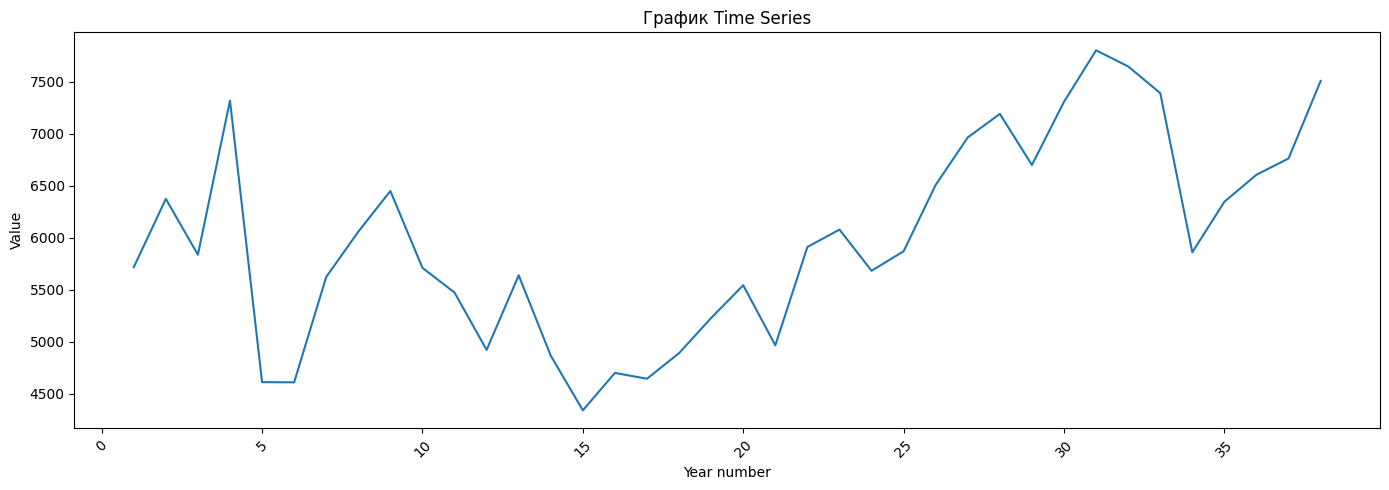

In [5]:
plt.figure(figsize=(14, 5))
sns.lineplot(x=df['Year number'], y=df["Value"])

plt.title('График Time Series')
plt.xlabel('Year number')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Делим на train/test

In [6]:
train_df, test_df = df[:-4], df[-4:]
train_timeseries, test_timeseries = train_df["Value"], test_df["Value"]

In [7]:
# train_df
# test_df

Строим графики acf, pacf

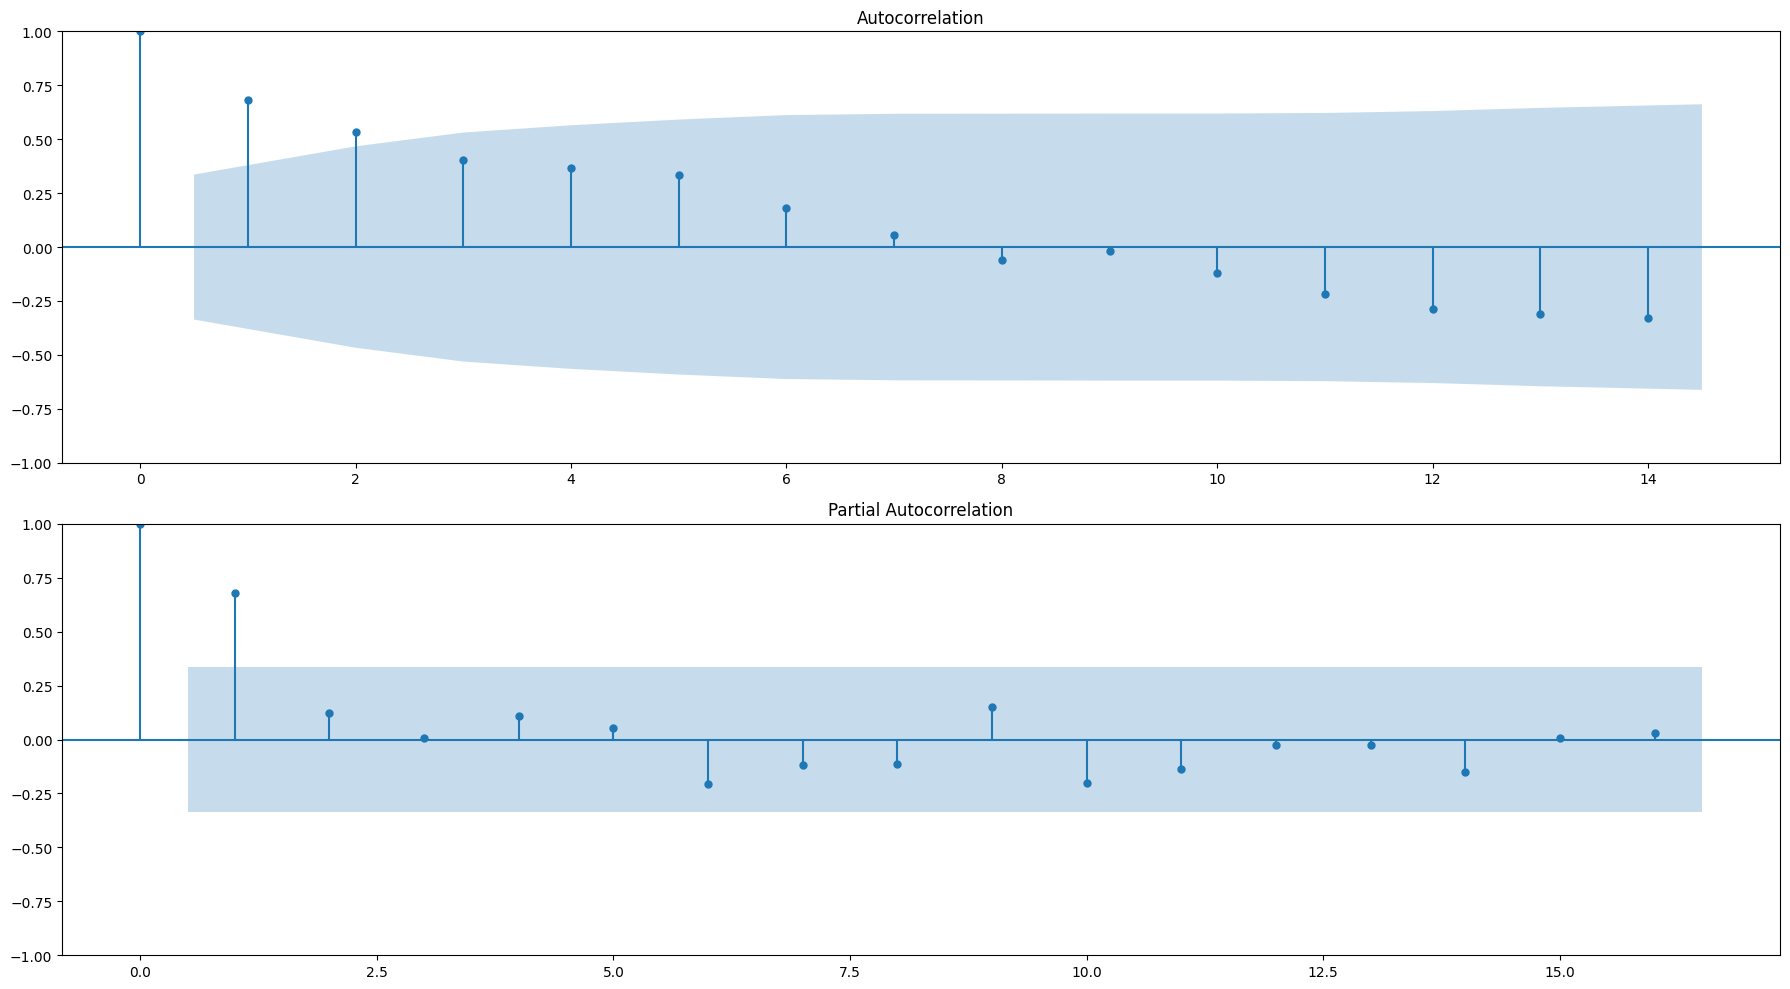

In [8]:
plt.figure(figsize=(18, 10))
plt.subplot(211)
plot_acf(train_timeseries, lags=14, ax=plt.gca())
plt.subplot(212)
plot_pacf(train_timeseries, method="ywmle", lags=16, ax=plt.gca())
plt.tight_layout()
plt.show()

Медленное убывание на графике autocorrelation указывает нам, что необходимо сделать разность, привести ряд к стационарному виду.

In [9]:
from copy import deepcopy

cur_time_series = deepcopy(train_timeseries)

cur_time_series = cur_time_series.diff().dropna()

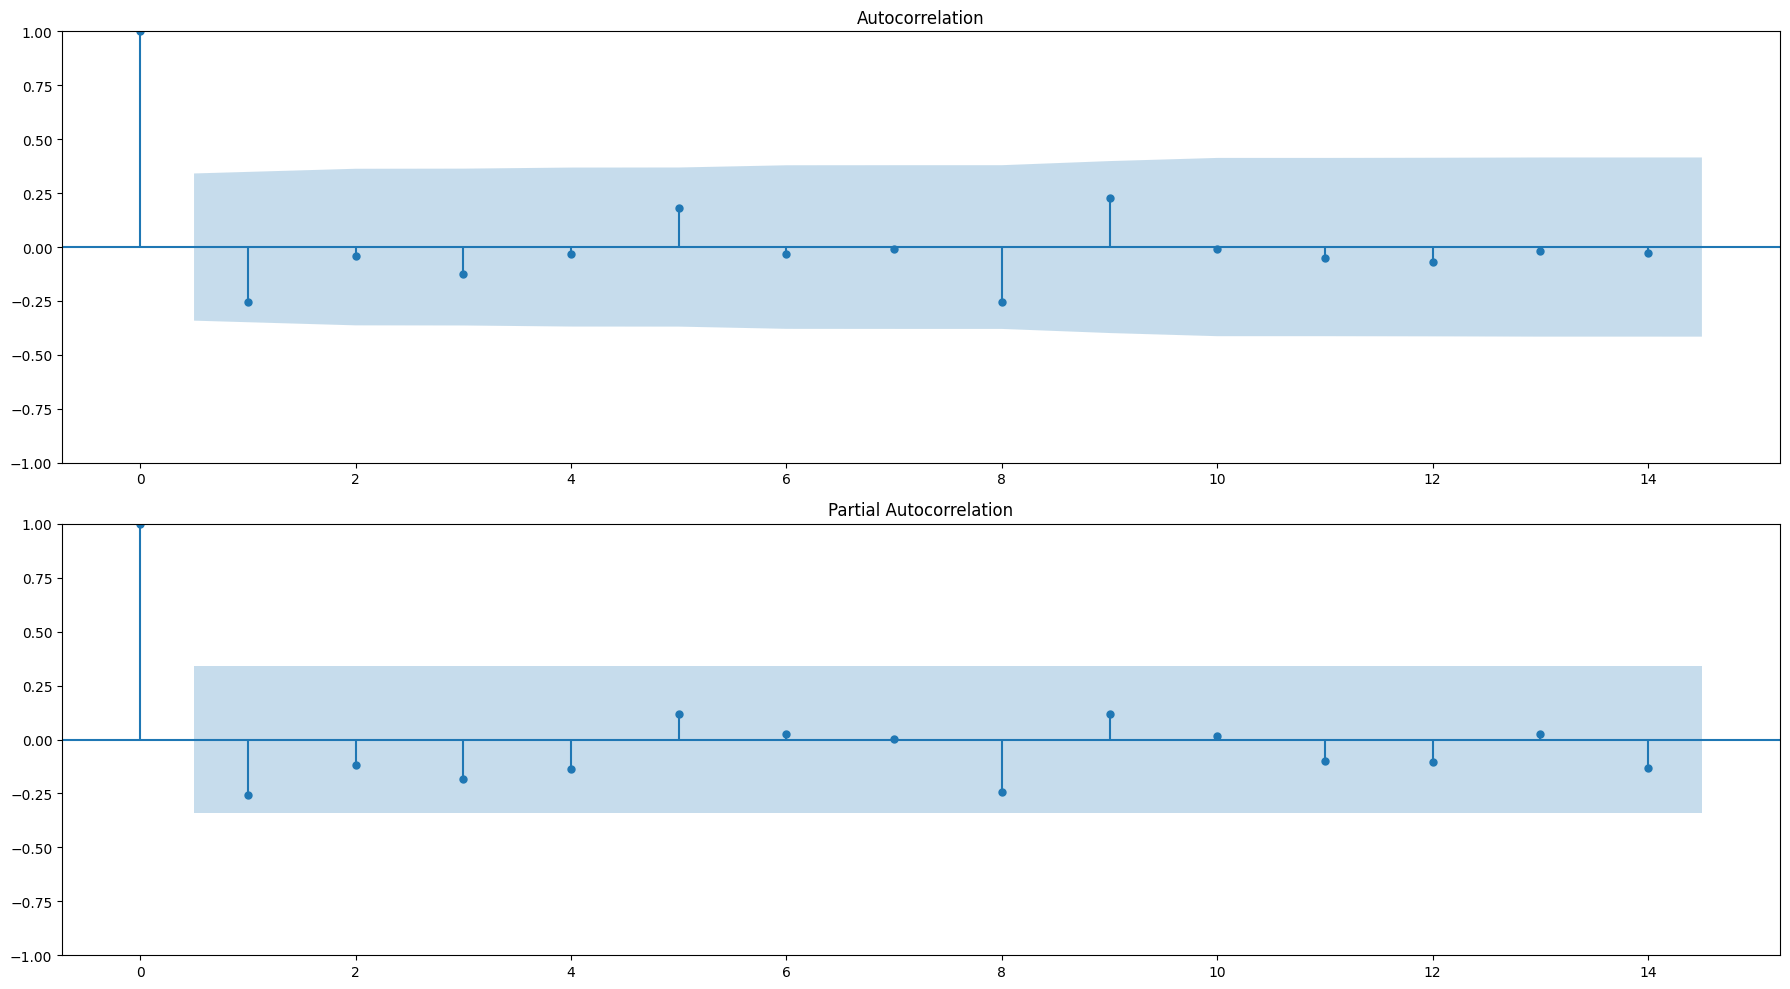

In [10]:
plt.figure(figsize=(18, 10))
plt.subplot(211)
plot_acf(cur_time_series, lags=14, ax=plt.gca())
plt.subplot(212)
plot_pacf(cur_time_series, method="ywmle", lags=14, ax=plt.gca())
plt.tight_layout()
plt.show()

- Используя дифференцирование (взятие разности) лишь один раз мы смогли добиться стационарности ряда.

- d = 1

Подберем p и q

## Первый вариант

Попробуем подобрать по AIC.

In [11]:
best_aic = np.inf
best_order = None
results = []

for p, q in itertools.product(range(4), range(4)):
    try:
        m = ARIMA(train_timeseries, order=(p, 1, q)).fit(method_kwargs={"max_iter": 10000})
        results.append((p, 1, q, m.aic, m.bic))
        if m.aic < best_aic:
            best_aic = m.aic
            best_order = (p, 1, q)
    except:
        continue

print(f'Лучший порядок: {best_order}, AIC: {best_aic:.2f}')

# Топ-5 моделей
results_df = pd.DataFrame(results, columns=['p','d','q','AIC','BIC'])
print(results_df.sort_values('AIC').head())

Лучший порядок: (0, 1, 0), AIC: 534.52
   p  d  q         AIC         BIC
0  0  1  0  534.519023  536.015530
1  0  1  1  534.996498  537.989513
4  1  1  0  535.462990  538.456005
5  1  1  1  535.472666  539.962189
2  0  1  2  535.648439  540.137962


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [12]:
best_q_aic, bes_p_aic = 0, 0

Берем для начала p = 0 и q = 0.

In [13]:
best_model_fitted = ARIMA(train_timeseries, order=(best_q_aic, 1, best_q_aic)).fit()
print(best_model_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                   34
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -266.260
Date:                Sat, 16 May 2026   AIC                            534.519
Time:                        23:02:21   BIC                            536.016
Sample:                             0   HQIC                           535.023
                                 - 34                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      5.963e+05    9.5e+04      6.275      0.000     4.1e+05    7.83e+05
Ljung-Box (L1) (Q):                   2.38   Jarque-Bera (JB):                18.97
Prob(Q):                              0.12   Pr

Построим график для residuals

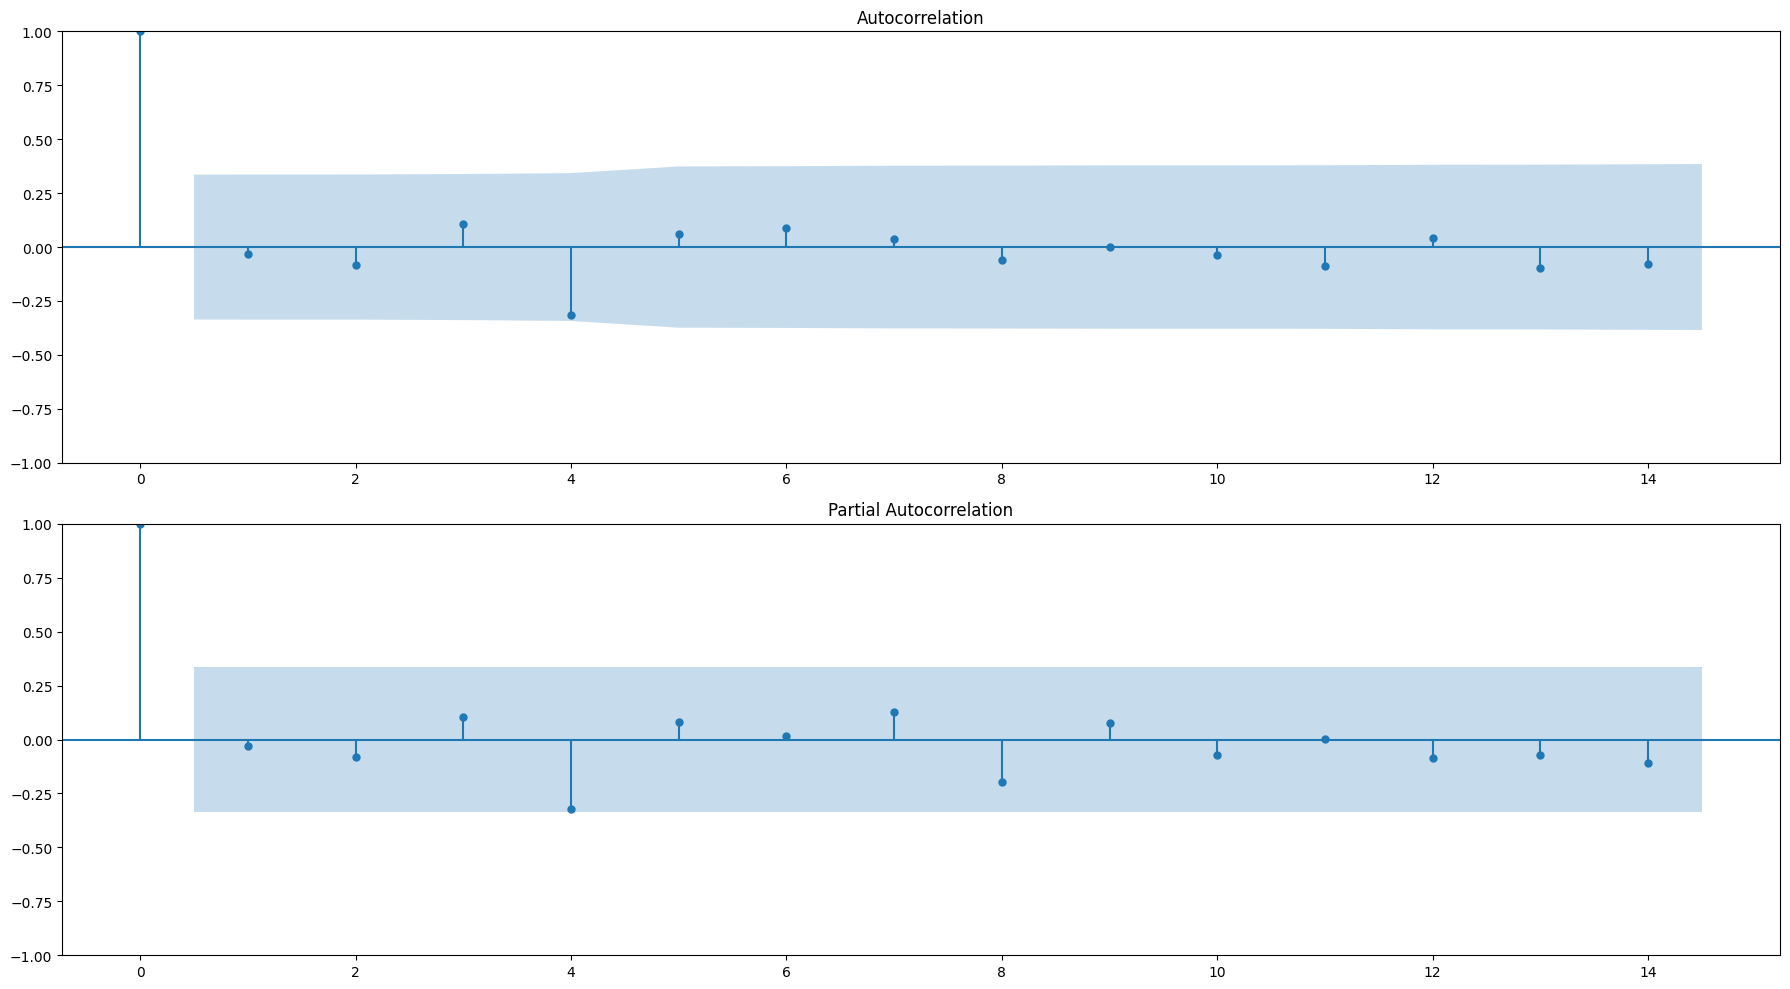

In [14]:
plt.figure(figsize=(18, 10))
plt.subplot(211)
plot_acf(best_model_fitted.resid, lags=14, ax=plt.gca())
plt.subplot(212)
plot_pacf(best_model_fitted.resid, method="ywmle", lags=14, ax=plt.gca())
plt.tight_layout()
plt.show()

- Остатки - почти белый шум, невозможно ничего дополнительного извлечь.

Сделаем прогноз

In [15]:
forecast_steps = 4
forecast_arima = best_model_fitted.forecast(steps=forecast_steps)
print(forecast_arima)

34    5861.5
35    5861.5
36    5861.5
37    5861.5
Name: predicted_mean, dtype: float64


Построим график

In [16]:
predict_arima = best_model_fitted.predict(0, 38)

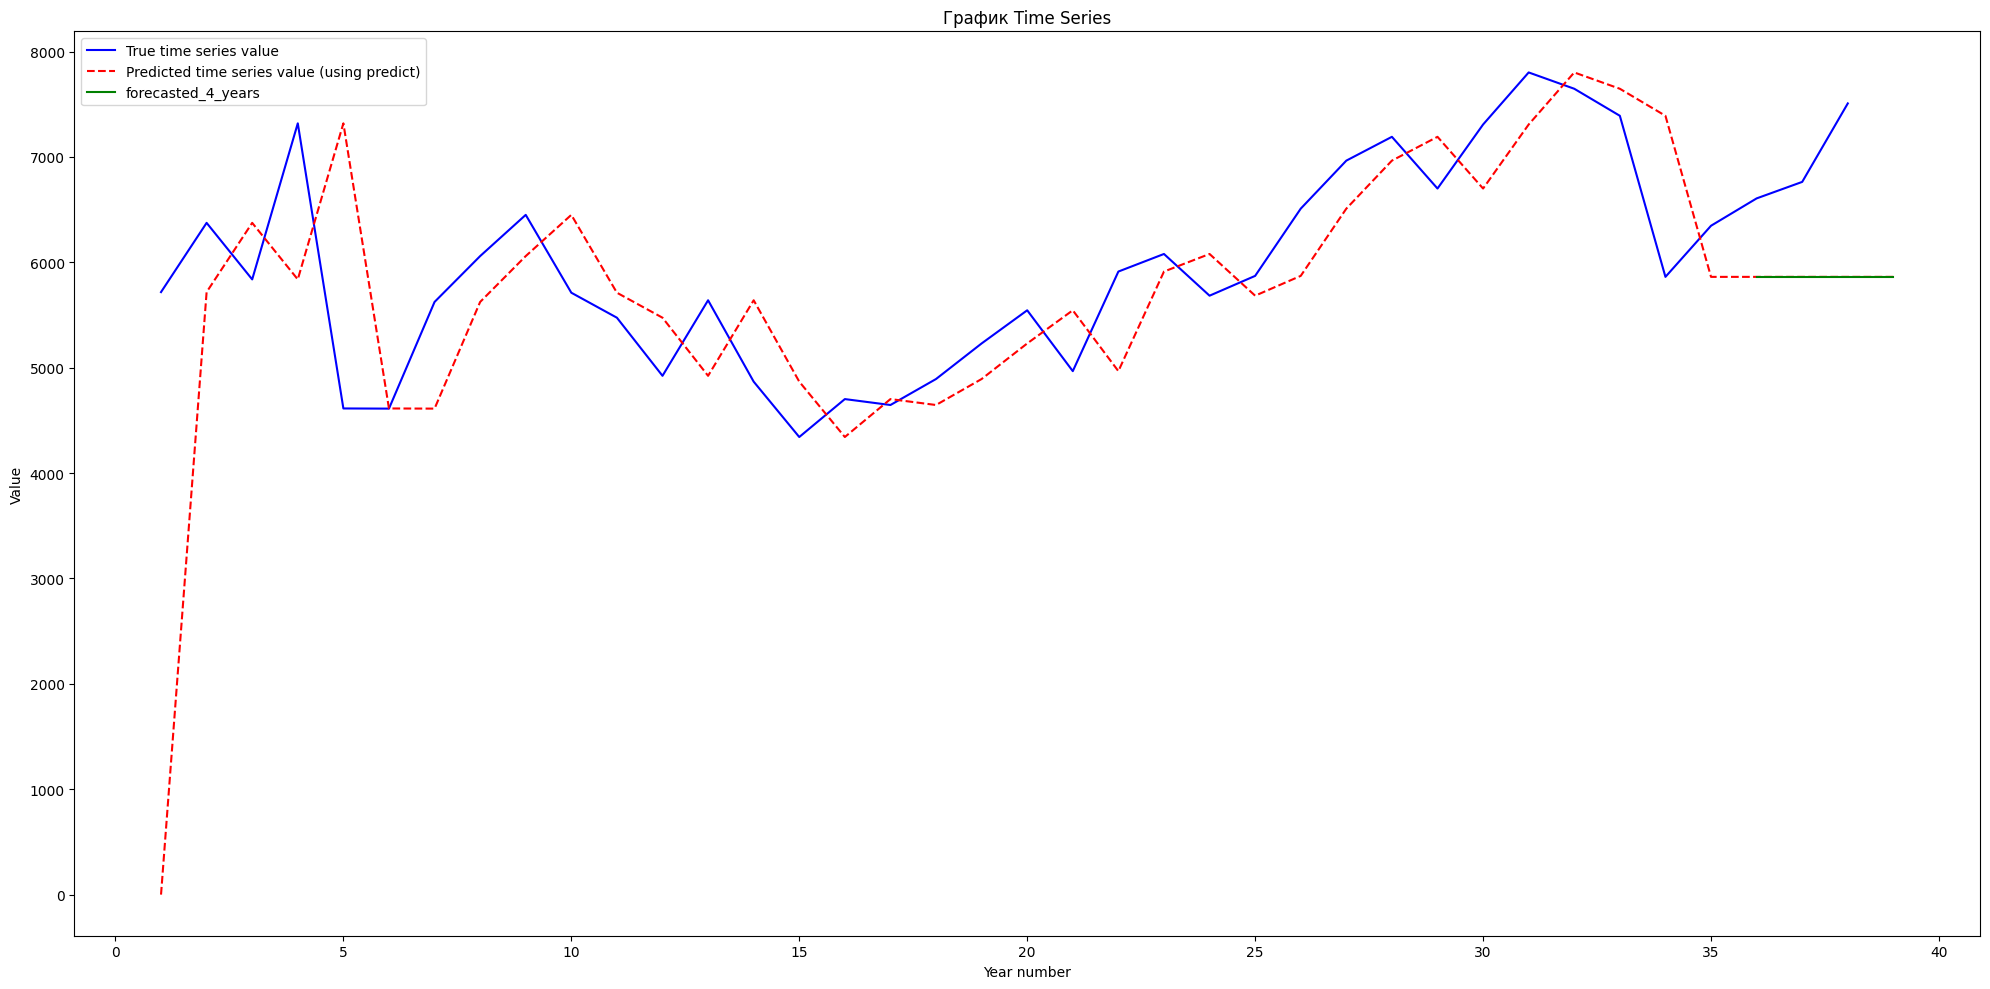

In [17]:
fig, ax = plt.subplots(figsize=(20, 10))

ax.plot(np.arange(1, len(df["Value"]) + 1), df["Value"], label="True time series value", color="blue")
ax.plot(np.arange(1, len(predict_arima) + 1), predict_arima, "--", label="Predicted time series value (using predict)", color="red")
ax.plot(np.arange(len(predict_arima) + 1 - 4, len(predict_arima) + 1), forecast_arima, label="forecasted_4_years", color="green")

plt.legend()
plt.title('График Time Series')
plt.xlabel('Year number')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

Посчитаем метрики

In [18]:
mse_val = mean_squared_error(test_timeseries, forecast_arima)
mae_val = mean_absolute_error(test_timeseries, forecast_arima)
mape_val = mean_absolute_percentage_error(test_timeseries, forecast_arima)
print(f"[MSE] = {mse_val}")
print(f"[MAE] = {mae_val}")
print(f"[MAPE] = {mape_val}")

[MSE] = 1077749.1124999998
[MAE] = 944.2249999999999
[MAPE] = 0.13541514717617031


## Второй вариант

Посмотрим теперь, что было бы, если бы мы взяли другие p, q. Допустим по графикам.

По графикам ACF, PACF оцениваем p=1, q=1.

In [19]:
best_model_fitted = ARIMA(train_timeseries, order=(1, 1, 1)).fit()
print(best_model_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                   34
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -264.736
Date:                Sat, 16 May 2026   AIC                            535.473
Time:                        23:02:21   BIC                            539.962
Sample:                             0   HQIC                           536.983
                                 - 34                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6131      0.288      2.127      0.033       0.048       1.178
ma.L1         -0.8680      0.199     -4.351      0.000      -1.259      -0.477
sigma2      5.233e+05   1.41e+05      3.711      0.0

Также смотрим на остатки.

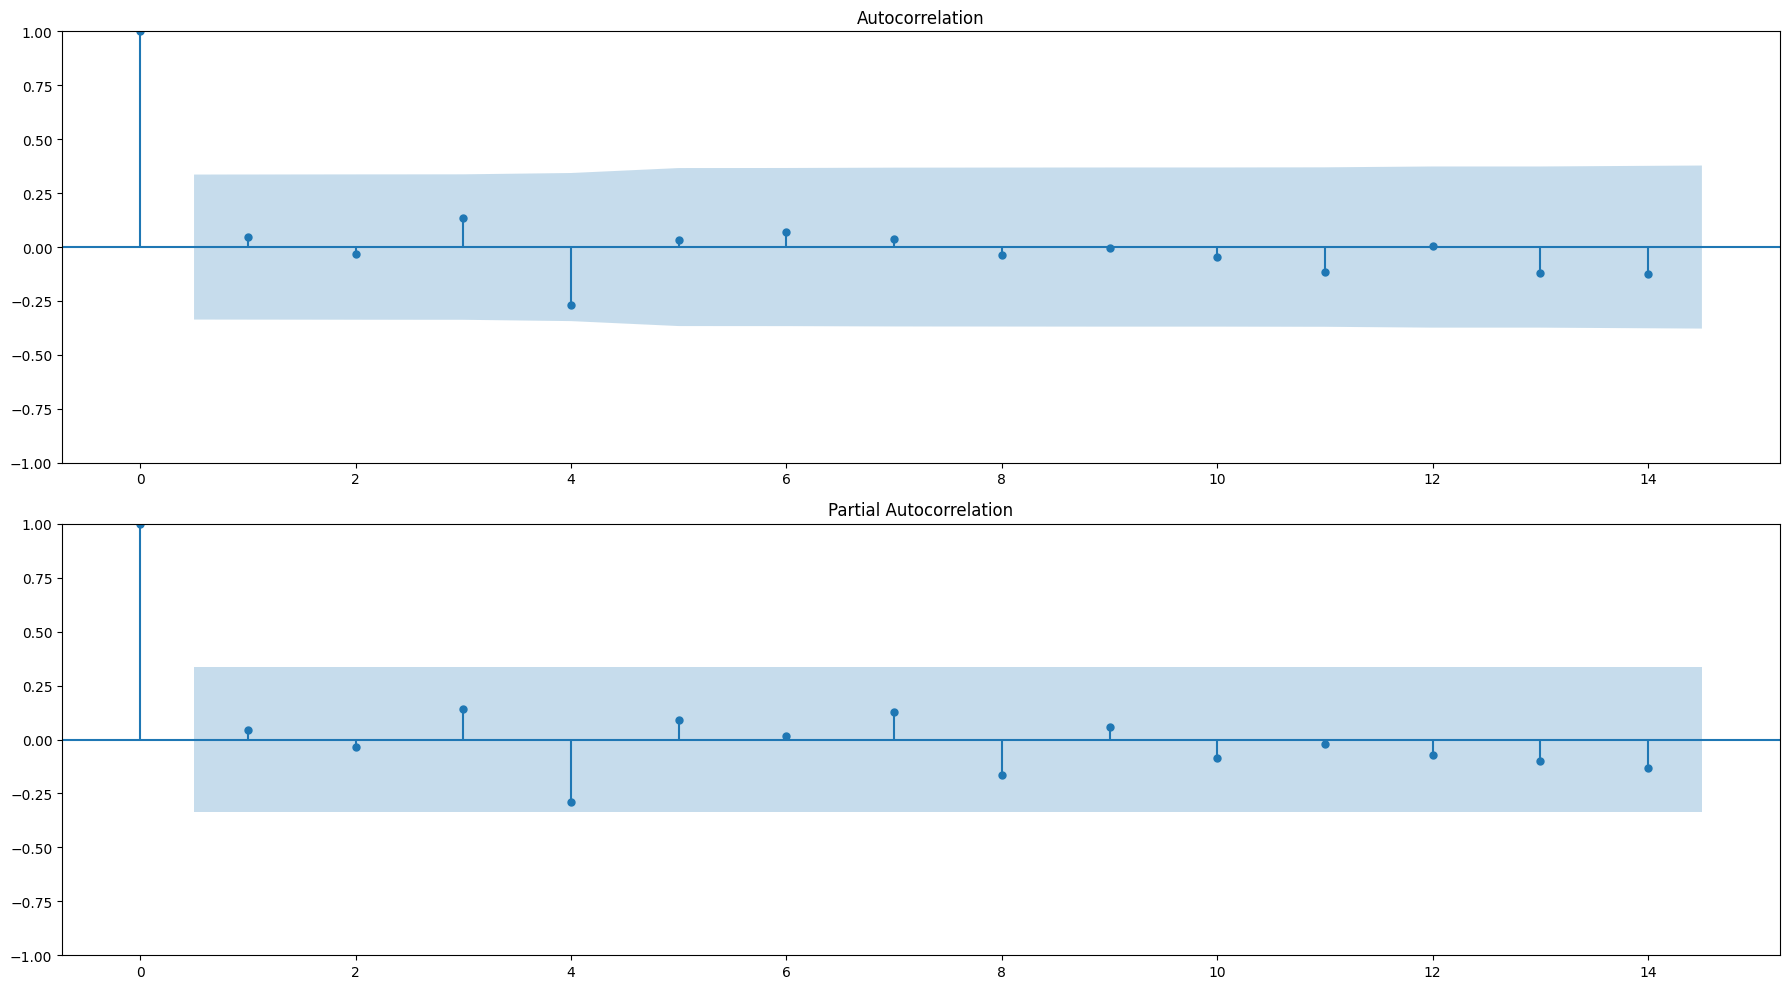

In [20]:
plt.figure(figsize=(18, 10))
plt.subplot(211)
plot_acf(best_model_fitted.resid, lags=14, ax=plt.gca())
plt.subplot(212)
plot_pacf(best_model_fitted.resid, method="ywmle", lags=14, ax=plt.gca())
plt.tight_layout()
plt.show()

Сделаем прогноз и построим график и оценим mase, mae, mape, как до этого

In [21]:
forecast_steps = 4
forecast_arima = best_model_fitted.forecast(steps=forecast_steps)
print(forecast_arima)

34    6074.817499
35    6205.604238
36    6285.790679
37    6334.953656
Name: predicted_mean, dtype: float64


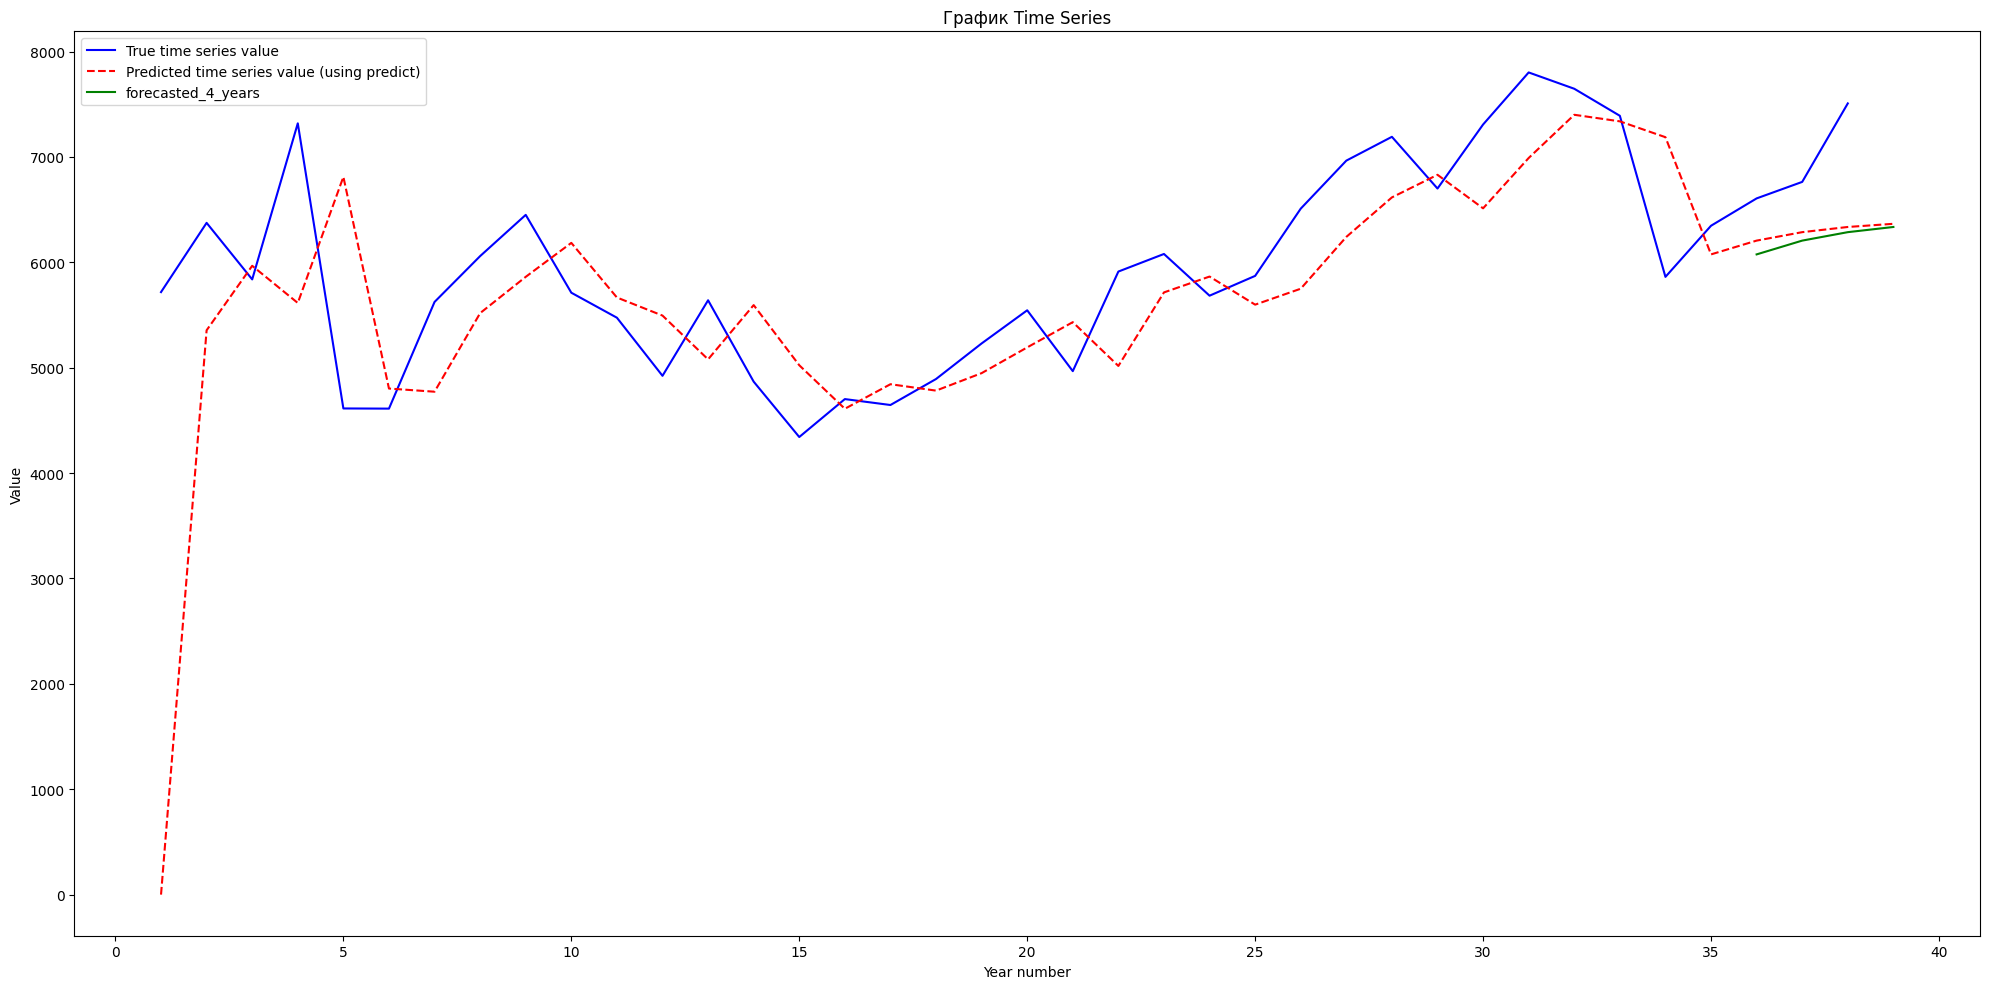

In [22]:
predict_arima = best_model_fitted.predict(0, 38)

fig, ax = plt.subplots(figsize=(20, 10))

ax.plot(np.arange(1, len(df["Value"]) + 1), df["Value"], label="True time series value", color="blue")
ax.plot(np.arange(1, len(predict_arima) + 1), predict_arima, "--", label="Predicted time series value (using predict)", color="red")
ax.plot(np.arange(len(predict_arima) + 1 - 4, len(predict_arima) + 1), forecast_arima, label="forecasted_4_years", color="green")

plt.legend()
plt.title('График Time Series')
plt.xlabel('Year number')
plt.ylabel('Value')
plt.tight_layout()
plt.show()
# plt.show()

In [23]:
mse_val = mean_squared_error(test_timeseries, forecast_arima)
mae_val = mean_absolute_error(test_timeseries, forecast_arima)
mape_val = mean_absolute_percentage_error(test_timeseries, forecast_arima)
print(f"[MSE] = {mse_val}")
print(f"[MAE] = {mae_val}")
print(f"[MAPE] = {mape_val}")

[MSE] = 459097.4699006381
[MAE] = 580.4334818014638
[MAPE] = 0.08253904675246065


- Выбор лучших p, q по AIC не всегда дает лучший результат.

Попробуем посмотреть какие p, q были бы лучшими с точки зрения mape на тестовом множестве

In [24]:
best_p, best_q, best_mape = None, None, None

for p, q in itertools.product(range(4), range(4)):
    current_model = ARIMA(train_timeseries, order=(p, 1, q)).fit(method_kwargs={"maxiter": 1000})
    current_forecast = current_model.forecast(steps=forecast_steps)

    current_mape_val = mean_absolute_percentage_error(test_timeseries, current_forecast)

    if best_mape is None:
        best_p = p
        best_q = q
        best_mape = current_mape_val 
    else:
        if current_mape_val < best_mape:
            best_p = p
            best_q = q
            best_mape = current_mape_val
            
print(f"Grid best_p = {best_p}, best_q = {best_q}, best_mape = {best_mape:.5f}")    

Grid best_p = 0, best_q = 2, best_mape = 0.03743
